# Rejection sampling an initial mass function (IMF)
1. Sample stellar masses from the Kroupa initial mass function (IMF) below using rejection sampling.
2. Check the resulting synthetic population against the analytic function it was drawn from.

In [1]:
import numpy as np
from scipy import integrate
%matplotlib inline
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 1. The target: the Kroupa IMF

The IMF describes how many stars form at each mass. The [Kroupa (2001)](https://ui.adsabs.harvard.edu/abs/2001MNRAS.322..231K) IMF (see also https://arxiv.org/abs/2410.07311 for review) is a **broken power law**:

$$
\xi(m) \propto
\begin{cases}
(m / m_{\rm break})^{-\alpha_1}, & m_{\rm min} \le m < m_{\rm break} \\
(m / m_{\rm break})^{-\alpha_2}, & m_{\rm break} \le m \le m_{\rm max}
\end{cases}
$$

with $\alpha_1 = 1.3$ (shallow, low-mass end), $\alpha_2 = 2.3$ (steep, high-mass end), and a break at $m_{\rm break} = 0.5\,M_\odot$. 
We'll sample over $m \in [0.08, 100]\,M_\odot$.

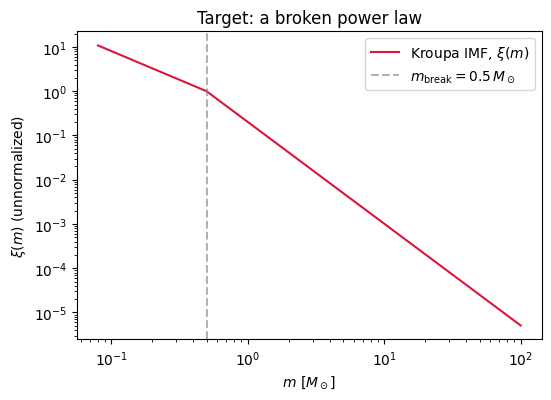

In [2]:
m_min, m_max = 0.08, 100.0
m_break = 0.5
alpha1, alpha2 = 1.3, 2.3

def kroupa_shape(m):
    ''' unnormalized Kroupa IMF shape
    '''
    m = np.asarray(m, dtype=float)
    return np.where(m < m_break, (m / m_break)**(-alpha1), (m / m_break)**(-alpha2))

mgrid = np.logspace(np.log10(m_min), np.log10(m_max), 500)

plt.figure(figsize=(6, 4))
plt.loglog(mgrid, kroupa_shape(mgrid), color="crimson", label=r"Kroupa IMF, $\xi(m)$")
plt.axvline(m_break, color="gray", linestyle="--", alpha=0.6, label=r"$m_{\rm break}=0.5\,M_\odot$")
plt.xlabel(r"$m\ [M_\odot]$")
plt.ylabel(r"$\xi(m)$ (unnormalized)")
plt.legend()
plt.title("Target: a broken power law")
plt.show()

## 2. Choose a proposal that envelopes the target

We need a proposal $q(m)$ that's easy to sample from and satisfies $\xi(m) \le M\,q(m)$ for every $m$ in range, for some constant $M$.